# 第49篇 | 决策树：直观易懂的分类器

> 这是「数据分析从入门到精通」系列的第 49 篇。特征工程做好了，这篇来学第一个真正意义上的机器学习算法——决策树。决策过程像 if-else 一样可读，人能看懂，是最有可解释性的分类器，也是后续随机森林、XGBoost 的基础。

嗨，我是小荷～ 今天学一个超级直观的算法：**决策树**。

---

## 一、什么是决策树？

决策树广泛应用于分类和回归问题，它通过树状结构来表示决策过程，每个内部节点代表一个特征或属性的测试，每个分支代表测试的结果，每个叶节点代表一个类别或值。

- 若目标变量取值为离散类别，对应的树模型称为分类树：这类树中，叶子节点代表类别标签，分支由特征条件组合构成，样本沿着分支最终归入对应类别。
- 若目标变量为连续数值（多为实数），则该决策树称作回归树。广义上，回归树思想还可拓展至各类带有相异度度量的数据，例如类别序列数据。

凭借逻辑直观、结构简洁的优势，决策树是主流机器学习算法之一；生成的规则易于解读、便于绘图展示，即便没有统计学基础也能看懂。

在本篇我们只用决策树进行分类。分类模型依据特征取值将数据集递归地划分成各个节点。为筛选最优分割条件，模型借助不纯度指标（impurity metrics）衡量节点内类别混杂程度。基尼不纯度（Gini Impurity）与熵（Entropy）是决策树常用的两种划分评判标准，二者均可量化数据集的混杂 / 纯净程度，引导模型选择划分方案，使拆分后的子集类别更单一。本篇第五部分我们会介绍决策树的两种构建指标：基尼指数（Gini Index）和基于信息熵（Entropy）来计算的信息增益（Information Gain）。

**核心思想**：通过一系列规则（问题）把数据分到不同的"叶子"节点，每个叶子代表一个预测结果。

**举个例子**：判断一个人会不会买iPhone

In [ ]:
收入 > 8000?
├── 是 → 年龄 < 30?
│         ├── 是 → 买！
│         └── 否 → 不买
└── 否 → 不买


## 二、决策树实现

来，咱们用鸢尾花数据集来实现一个真正的决策树。鸢尾花数据集是经典且简易的多分类数据集。它是机器学习入门标配数据集，包含150条数据，3 个品种分类。

数据集一共 4 个输入特征、1 个分类输出标签。

输入特征，也就是数据集的data字段，4个字段的含义分别是：

- sepal length in cm：花萼长度（厘米）
- sepal width in cm：花萼宽度（厘米）
- petal length in cm：花瓣长度（厘米）
- petal width in cm：花瓣宽度（厘米）

目标变量target字段有3个值：['setosa' 'versicolor' 'virginica']

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, load_iris
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print("🌳 决策树入门")

# 用鸢尾花数据集演示
iris = load_iris()  # iris数据集总共有150条记录，
X, y = iris.data, iris.target

# 为了可视化方便，只用两个特征
X_2d = X[:, [0, 2]]  # 花萼长度 和 花瓣长度

print(f"数据形状: {X_2d.shape}")
print(f"类别: {iris.target_names}")

# 划分数据
X_train, X_test, y_train, y_test = train_test_split(X_2d, y, test_size=0.2, random_state=42)

# 训练决策树
dt = DecisionTreeClassifier(max_depth=3, random_state=42)  # 限制深度便于可视化
dt.fit(X_train, y_train)

# 预测与评估
y_pred = dt.predict(X_test)
print(f"\n准确率: {accuracy_score(y_test, y_pred):.3f}")
print("分类报告:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))


🌳 决策树入门
数据形状: (150, 2)
类别: ['setosa' 'versicolor' 'virginica']

准确率: 0.967
分类报告:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.89      0.94         9
   virginica       0.92      1.00      0.96        11

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.97        30
weighted avg       0.97      0.97      0.97        30



可以看到模型在数据集准确率为96.7%，意思是预测对了 30 个里的 29 个，几乎完美。对山鸢尾（setosa）实现100% 正确分类，其余两个类别也保持极高的精确率与召回率，说明模型分类效果稳定、可靠。

---

## 三、可视化决策树

看完上面的代码还是有点懵对不对？完全是个黑盒的过程，还是不知道模型到底是怎样做的决策。我们可以把训练好的决策树，转换成人类能看懂的文字判断规则，清晰展示模型是根据什么条件一步步判断花的品种的。

In [28]:
# 方法1：文本形式展示
print("\n决策树规则（文本形式）:")
print("-" * 40)
tree_rules = export_text(dt, feature_names=['花萼长度', '花瓣长度'])
print(tree_rules)



决策树规则（文本形式）:
----------------------------------------
|--- 花瓣长度 <= 2.45
|   |--- class: 0
|--- 花瓣长度 >  2.45
|   |--- 花瓣长度 <= 4.75
|   |   |--- 花萼长度 <= 4.95
|   |   |   |--- class: 1
|   |   |--- 花萼长度 >  4.95
|   |   |   |--- class: 1
|   |--- 花瓣长度 >  4.75
|   |   |--- 花瓣长度 <= 5.05
|   |   |   |--- class: 2
|   |   |--- 花瓣长度 >  5.05
|   |   |   |--- class: 2



翻译过来就是：
- 如果花瓣长度 ≤ 2.45 厘米，直接判定为：0 号品种（setosa）。
- 如果花瓣长度 > 2.45 且 ≤ 4.75，不管花萼长度是多少，全部判定为：1 号品种（versicolor）。
- 如果花瓣长度 > 4.75，不管具体多大，全部判定为：2 号品种（virginica）。

文字版不够直观？画图看看树长什么样。

可以看到，模型首个分裂选用了花瓣长度 (cm)的特征，选取了 2.45作为分界阈值。

- gini：代表节点的基尼不纯度，也就是前面提到的纯度计算指标。
- samples：流经该节点的训练样本数量；本节点是根节点，因此包含全部样本。

根节点的左分支为叶子节点。叶子是决策树的末端节点，不再向下分裂，样本抵达叶子即完成分类。本例中有 40 个训练样本落在该叶节点，全部被判定为 1 类（山鸢尾 setosa）。

而右侧分支会再次切分，继续向下生成子节点、逐层判定，直至完成剩余样本的分类。


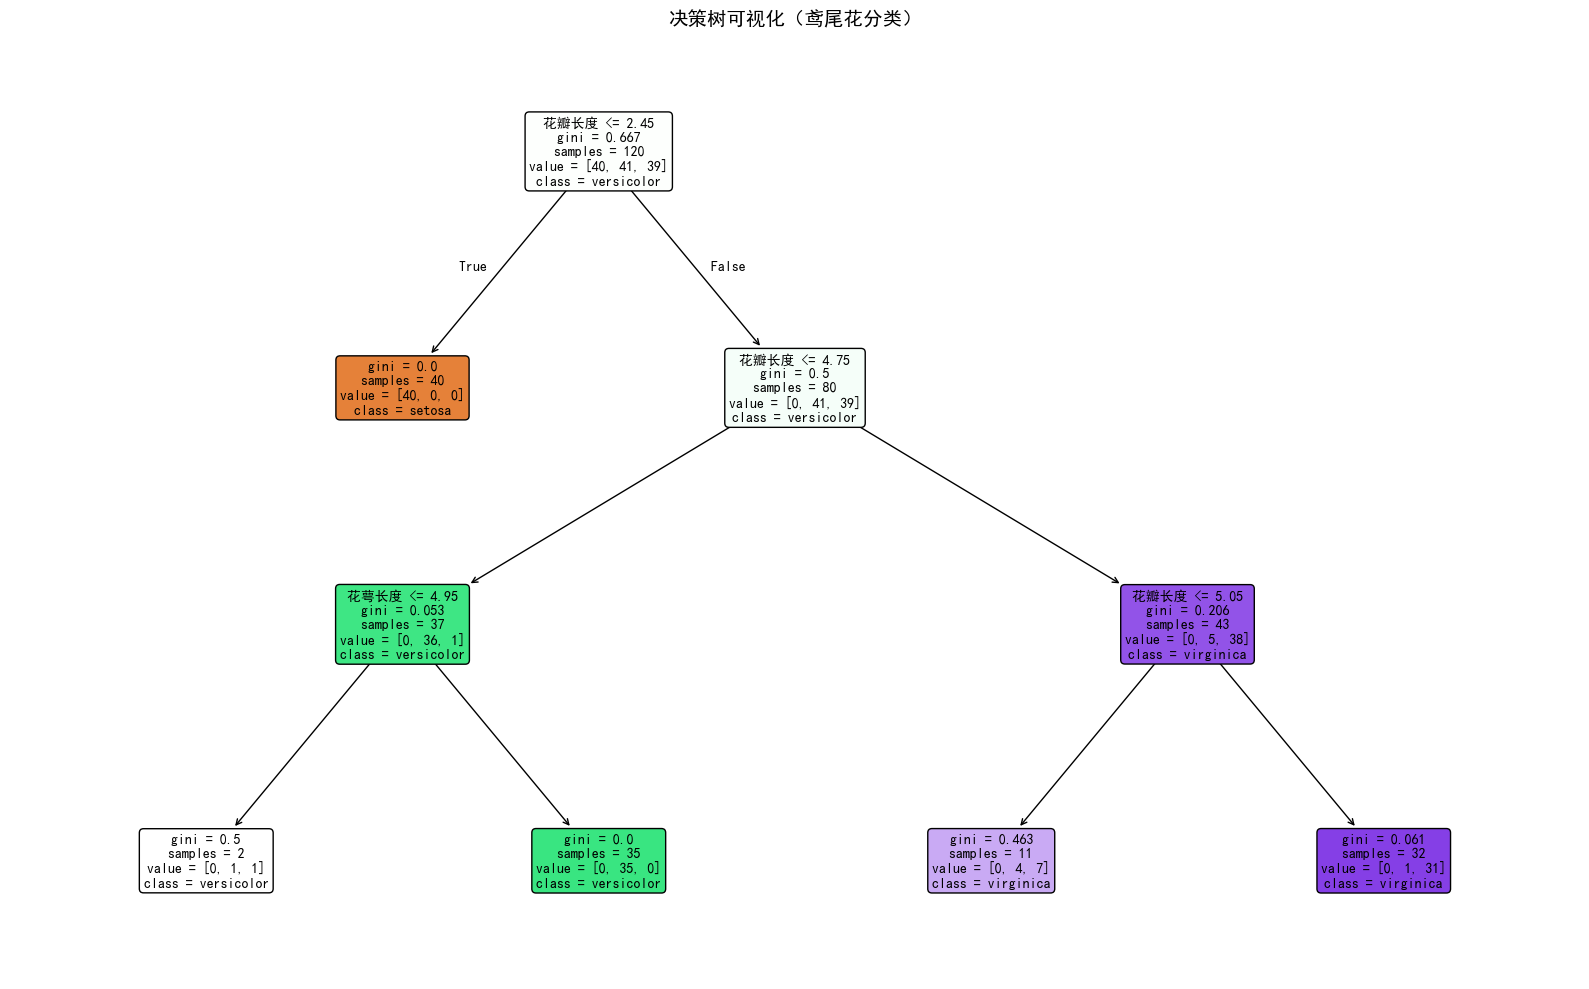

In [29]:
# 方法2：图形可视化
fig, ax = plt.subplots(figsize=(16, 10))
plot_tree(dt, 
          feature_names=['花萼长度', '花瓣长度'],
          class_names=iris.target_names,
          filled=True,  # 填充颜色
          rounded=True,  # 圆角节点
          fontsize=10,
          ax=ax)
plt.title('决策树可视化（鸢尾花分类）', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---

## 四、理解决策边界

决策树（Decision Tree）是基于轴对称切分的（正交切分），它会对特征进行“横平竖直”的块状切分。

它分裂数据的逻辑非常单纯：每次只挑选一个特征，然后在上面切一刀。

- 比如第一刀：看“花瓣长度是否 < 2.45 厘米？ ->  在图上横着切一刀。
- 第二刀：看“花瓣长度是否 <= 4.75 厘米？ ->  在图上再横着切一刀。
- 第三刀：看“花萼长度是否 < 4.95 厘米？” -> 在图上竖着切一刀。
- 第四刀：看“花瓣长度是否 <= 5.05 厘米？ ->  在图上再横着切一刀。
- ...

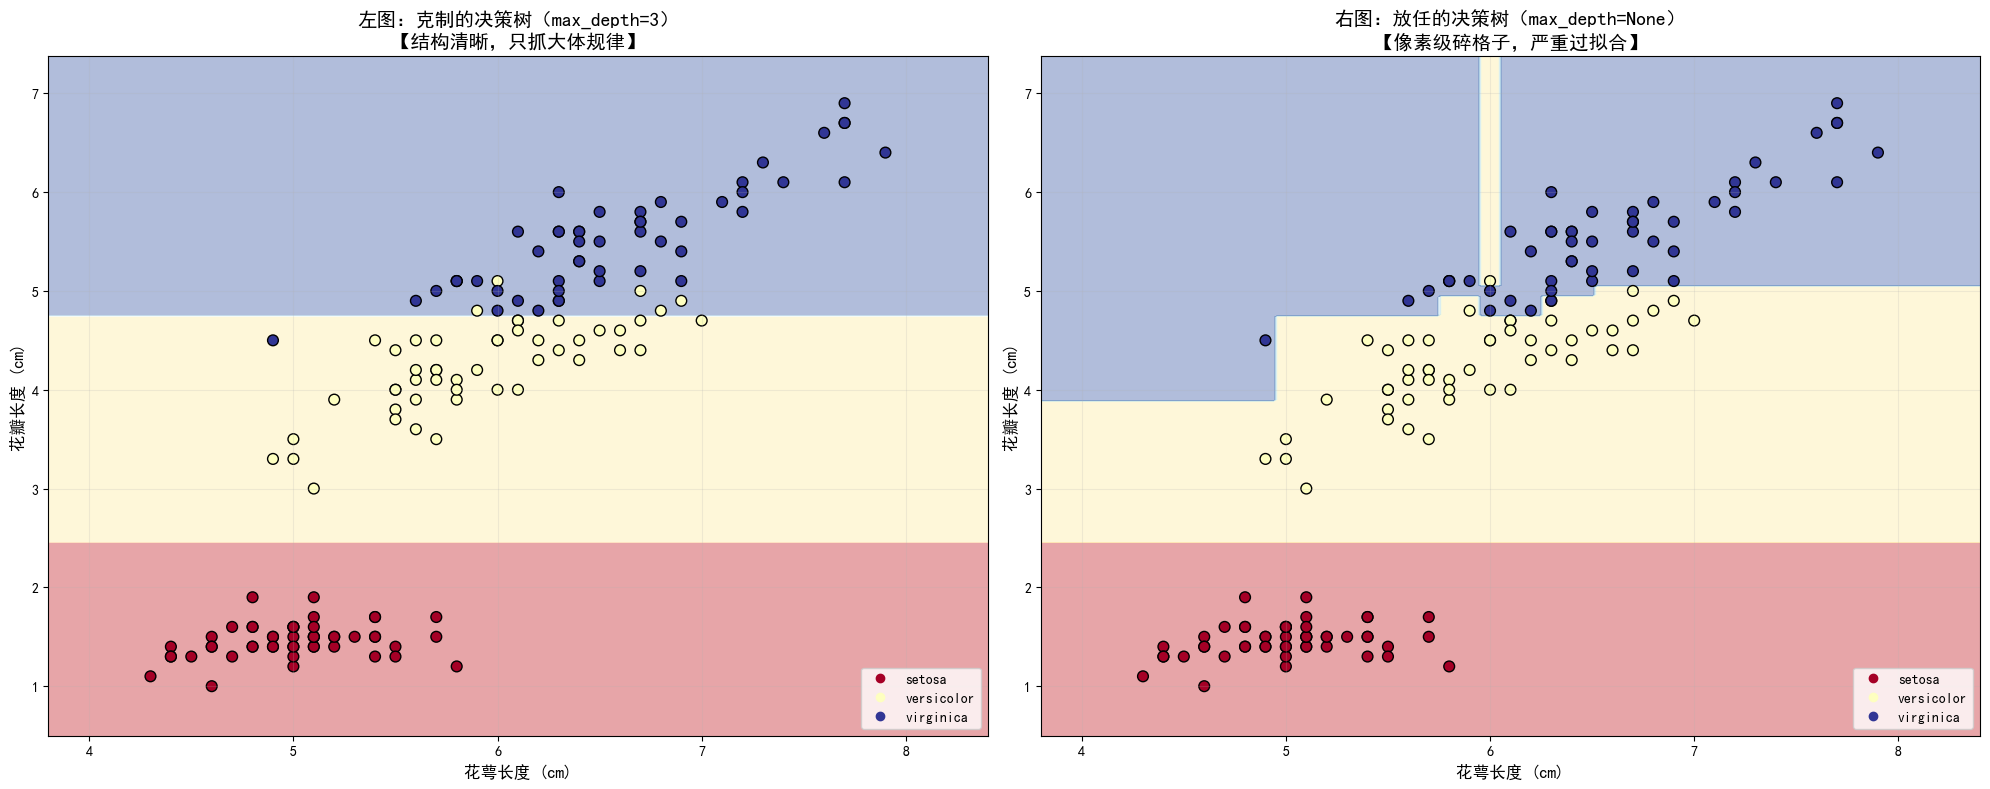

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier

# ==========================================
# 0. 环境初始化配置（防止中文乱码和负号报错）
# ==========================================
plt.rcdefaults()
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS'] 
plt.rcParams['axes.unicode_minus'] = False                                         
plt.rcParams['mathtext.fontset'] = 'dejavusans'                                   

# ==========================================
# 1. 训练两个不同的决策树模型
# ==========================================
# 模型 1：限制深度的健康模型
dt_limited = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_limited.fit(X_2d, y)

# 模型 2：不限制深度的过拟合模型（自由生长）
dt_unlimited = DecisionTreeClassifier(max_depth=None, random_state=42)
dt_unlimited.fit(X_2d, y)

# ==========================================
# 2. 创建画布：1 行 2 列的并排格局
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
cmap = plt.cm.RdYlBu

# 创建预测网格
h = 0.02
x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
y_min, y_max = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
grid_points = np.column_stack((xx.ravel(), yy.ravel()))

# ------------------------------------------
# 【左图】：max_depth=3（你会看到3个大长方形）
# ------------------------------------------
Z1 = dt_limited.predict(grid_points).reshape(xx.shape)
ax1.contourf(xx, yy, Z1, alpha=0.4, cmap=cmap)
scatter1 = ax1.scatter(X_2d[:, 0], X_2d[:, 1], c=y, cmap=cmap, edgecolors='k', s=60)
ax1.set_xlabel('花萼长度 (cm)', fontsize=12)
ax1.set_ylabel('花瓣长度 (cm)', fontsize=12)
ax1.set_title('左图：克制的决策树（max_depth=3）\n【结构清晰，只抓大体规律】', fontsize=14)

# ------------------------------------------
# 【右图】：max_depth=None（你会看到一些阶梯状的碎格子）
# ------------------------------------------
Z2 = dt_unlimited.predict(grid_points).reshape(xx.shape)
ax2.contourf(xx, yy, Z2, alpha=0.4, cmap=cmap)
scatter2 = ax2.scatter(X_2d[:, 0], X_2d[:, 1], c=y, cmap=cmap, edgecolors='k', s=60)
ax2.set_xlabel('花萼长度 (cm)', fontsize=12)
ax2.set_ylabel('花瓣长度 (cm)', fontsize=12)
ax2.set_title('右图：放任的决策树（max_depth=None）\n【像素级碎格子，严重过拟合】', fontsize=14)

# 添加图例（自动适配 iris 变量）
try:
    labels = list(iris.target_names)
except NameError:
    labels = ['类别0', '类别1', '类别2']
ax1.legend(handles=scatter1.legend_elements()[0], labels=labels, loc='lower right')
ax2.legend(handles=scatter2.legend_elements()[0], labels=labels, loc='lower right')

# ==========================================
# 3. 强力渲染拦截（双重保险防止两张图的刻度负号报错）
# ==========================================
fig.canvas.draw()
for ax in [ax1, ax2]:
    ax.set_xticklabels([t.get_text().replace('−', '-') for t in ax.get_xticklabels()])
    ax.set_yticklabels([t.get_text().replace('−', '-') for t in ax.get_yticklabels()])
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

左图是max_depth=3，右边是放任自流、不限深度的 max_depth=None.

- 可以看到，限制了 max_depth=3（最大深度只有 3 层），模型最多切了 7 刀（创建了 7 个分叉点），将空间分成了 8 个区域。但是在图里数出来的长方形数量只有3个，这是因为有些“刀”切在了同一个颜色的纯净区域内部，或者两层连续的刀痕在视觉上连成了一片大长方形。

- 如果你把深度限制放开，比如设置 max_depth=10（或者干脆不设，让树自由生长），奇观就会出现了：

  为了强行把混在红点里的绿点、混在蓝点里的红点给抠出来，决策树会开始变得极端和偏执。

  它会这里横着切一刀，那里竖着切一刀，像密集成像的像素点一样。

  最终，那条原本平滑的分类边界，会被决策树用无数个极小的、横平竖直的微型长方形死记硬背地拼凑出来。

当你看到大块长方形时，说明模型抓取的是宏观的主干规律；而当你看到密密麻麻的“阶梯碎格子”时，在机器学习里就叫做过拟合（Overfitting）——树太深了，它在企图死记硬背每一个噪声数据点。

这就是为什么在实际工业界中，我们玩决策树必须通过 max_depth、min_samples_leaf 等参数来给它“剪枝”（Pruning），或者干脆直接用随机森林（Random Forest）把无数棵树组合起来，把这些任性的碎格子给抹平。

### 剪枝

树太深容易过拟合，需要剪枝，这里演示通过修改min_samples_leaf来剪枝。


In [53]:
print("\n防止过拟合的参数:")
print("-" * 40)
print("""
1. max_depth: 树的最大深度
   - 限制树的复杂度
   - 常用值：3-10

2. min_samples_split: 分裂所需最小样本数
   - 防止节点样本过少
   - 常用值：2-20

3. min_samples_leaf: 叶子节点最小样本数
   - 防止叶子过于稀疏
   - 常用值：1-10

4. max_leaf_nodes: 最大叶子节点数
   - 直接限制树的规模
""")

# 对比不同参数
params_comparison = []
for min_samples in [2, 5, 10, 20]:
    dt_param = DecisionTreeClassifier(min_samples_split=min_samples, random_state=42)
    dt_param.fit(X_train, y_train)
    params_comparison.append({
        'min_samples_split': min_samples,
        '训练准确率': accuracy_score(y_train, dt_param.predict(X_train)),
        '测试准确率': accuracy_score(y_test, dt_param.predict(X_test)),
        '叶子节点数': dt_param.get_n_leaves()
    })

params_df = pd.DataFrame(params_comparison)
print("\n不同 min_samples_split 的效果:")
print(params_df.to_string(index=False))



防止过拟合的参数:
----------------------------------------

1. max_depth: 树的最大深度
   - 限制树的复杂度
   - 常用值：3-10

2. min_samples_split: 分裂所需最小样本数
   - 防止节点样本过少
   - 常用值：2-20

3. min_samples_leaf: 叶子节点最小样本数
   - 防止叶子过于稀疏
   - 常用值：1-10

4. max_leaf_nodes: 最大叶子节点数
   - 直接限制树的规模


不同 min_samples_split 的效果:
 min_samples_split    训练准确率    测试准确率  叶子节点数
                 2 0.991667 1.000000     13
                 5 0.983333 1.000000     11
                10 0.966667 1.000000      7
                20 0.950000 0.966667      6


---

## 五、决策树如何分裂？

决策树的核心是选择**最优分裂特征和分裂点**。常用指标有信息增益（Information Gain）和基尼不纯度（Gini Impurity）。

### 5.1 信息增益（Information Gain）

计算公式：

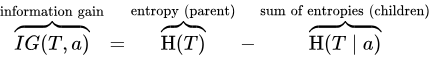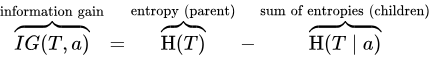

H(T)为数据集的熵，用来衡量数据的不确定性。

上面的公式即为：信息增益 = 分裂前的熵 - 分裂后的加权平均熵

熵的定义：

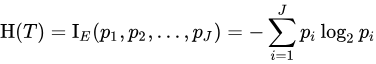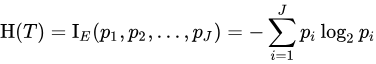

式中 p1,p2,... 为各类别的样本占比，所有占比之和等于 1，代表决策树节点分裂后，子节点中各个类别的样本占比。

In [42]:
# 信息熵计算示例
def entropy(labels):
    """计算信息熵"""
    _, counts = np.unique(labels, return_counts=True)
    probs = counts / len(labels)
    return -np.sum(probs * np.log2(probs + 1e-10))

# 示例
pure = [0, 0, 0, 0]  # 纯节点
mixed = [0, 0, 1, 1]  # 混合节点
very_mixed = [0, 1, 2, 0, 1, 2]  # 三类混合

print("信息熵示例:")
print(f"纯节点 {pure}: 熵 = {entropy(pure):.3f}")
print(f"混合节点 {mixed}: 熵 = {entropy(mixed):.3f}")
print(f"三类混合 {very_mixed}: 熵 = {entropy(very_mixed):.3f}")
print("\n熵越小，节点越纯（确定性越高）")


信息熵示例:
纯节点 [0, 0, 0, 0]: 熵 = -0.000
混合节点 [0, 0, 1, 1]: 熵 = 1.000
三类混合 [0, 1, 2, 0, 1, 2]: 熵 = 1.585

熵越小，节点越纯（确定性越高）


### 5.2 基尼不纯度（Gini Impurity）

Gini Impurity，设样本集合包含J个类别，各类别的占比为\(p_i\)（\(i=1,2…,J\)）。随机抽取一个样本，其属于第i类的概率为\(p_i\)；将该样本错分为其他类的概率为其余类别占比之和为：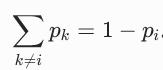

基尼不纯度，就是对全部类别，求取「类别概率 × 错分概率」并累加求和。计算公式：

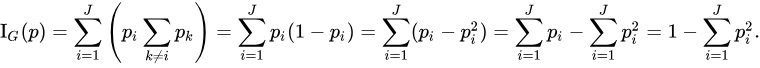

基尼数值越小，说明分类越纯；越大说明越乱。

下面来手写一个 Gini 函数，帮你看清楚不纯度是怎么算的：


In [43]:
def gini(labels):
    """计算基尼不纯度"""
    # 统计每个类别出现多少次
    # np.unique：找出所有不重复的类别；return_counts=True：同时返回每个类别出现多少次
    # counts = 每个类别的数量
    _, counts = np.unique(labels, return_counts=True)
    probs = counts / len(labels)  # 概率 = 该类数量 ÷ 总数量
    return 1 - np.sum(probs ** 2)  # 基尼 = 1 – (p₁² + p₂² + … + pₙ²)

print("\n基尼不纯度示例:")
print(f"纯节点 {pure}: Gini = {gini(pure):.3f}") # 基尼 = 0
print(f"混合节点 {mixed}: Gini = {gini(mixed):.3f}") #  基尼变大
print(f"三类混合 {very_mixed}: Gini = {gini(very_mixed):.3f}") # 非常混乱，基尼最大


基尼不纯度示例:
纯节点 [0, 0, 0, 0]: Gini = 0.000
混合节点 [0, 0, 1, 1]: Gini = 0.500
三类混合 [0, 1, 2, 0, 1, 2]: Gini = 0.667


### 5.3 熵和基尼指数到底有什么区别？

我们画图对比一下就知道了。熵和基尼指数的优缺点以及适合的场景，限于篇幅在此不做延伸。

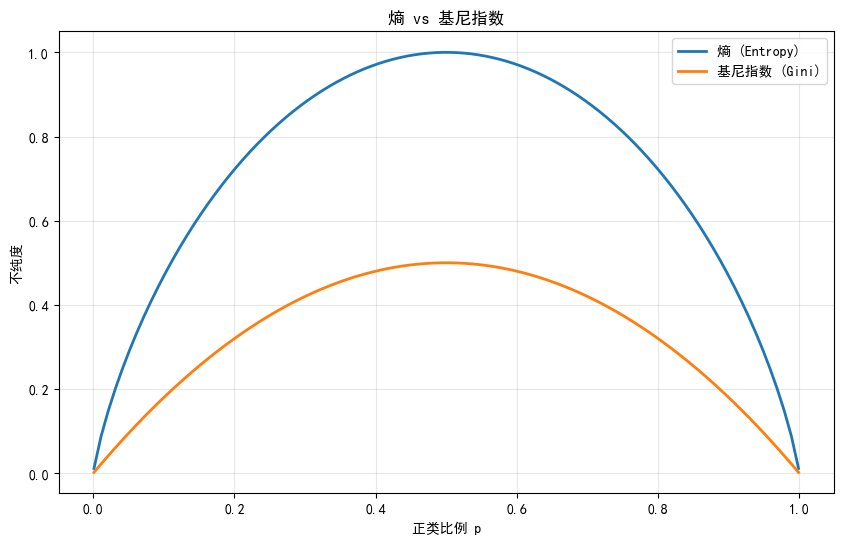

In [44]:
# 可视化熵 vs 基尼指数
p = np.linspace(0.001, 0.999, 100)  # 横坐标p：某一类样本在节点中的占比（0~1）
entropy_vals = -(p * np.log2(p) + (1-p) * np.log2(1-p)) 
gini_vals = 1 - (p**2 + (1-p)**2)

plt.figure(figsize=(10, 6))
plt.plot(p, entropy_vals, label='熵 (Entropy)', linewidth=2)
plt.plot(p, gini_vals, label='基尼指数 (Gini)', linewidth=2)
plt.xlabel('正类比例 p')
plt.ylabel('不纯度')
plt.title('熵 vs 基尼指数')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

熵与基尼指数趋势高度相似，均可作为决策树分裂的不纯度评判标准。

---

## 七、特征重要性

哪些特征对模型影响最大？这里我们还是以鸢尾花数据集为例来看特征重要性，模型会返回一棵树
dt_full 。


dt_full 不是单纯的数字，而是一整棵训练好的树，包含：
- 树结构信息
   - 每个节点用哪个特征分裂
   - 每个节点分裂阈值是多少
   - 哪些是叶子节点（最终分类）
   -树的深度、节点总数
- 训练相关数据
   - 每个节点的基尼不纯度 / 熵
   - 每个节点包含的样本数量（samples）
   - 每个节点中各类别的样本数（values）
   - 最终预测的类别（class）
- 模型参数
   - max_depth=5：树最大深度
   - criterion='gini'：默认使用基尼不纯度分裂
   - 特征重要性（哪些特征对分类最有用）

这里我们就是用dt_full.feature_importances_来判断特征的影响大小，可以看出花瓣长度（petal length）最重要。


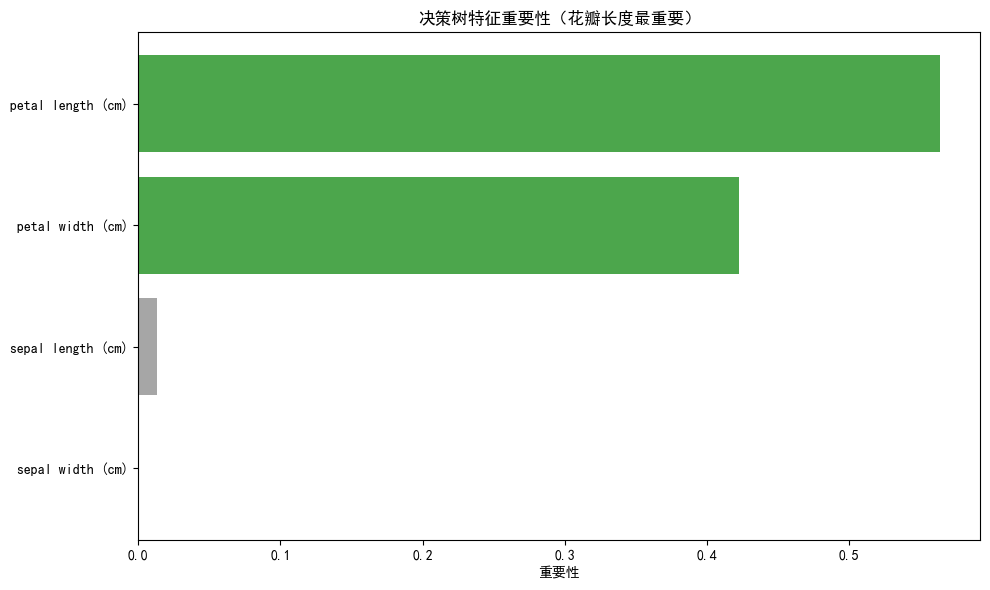

In [47]:
# 使用全部特征训练
dt_full = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_full.fit(X, y)

# 特征重要性
importance_df = pd.DataFrame({
    '特征': iris.feature_names,
    '重要性': dt_full.feature_importances_
}).sort_values('重要性', ascending=True)

plt.figure(figsize=(10, 6))
colors = ['green' if imp > 0.1 else 'gray' for imp in importance_df['重要性']]
plt.barh(importance_df['特征'], importance_df['重要性'], color=colors, alpha=0.7)
plt.xlabel('重要性')
plt.title('决策树特征重要性（花瓣长度最重要）')
plt.tight_layout()
plt.show()


---

## 八、综合实战：客户流失预测

学了一堆理论，来个完整的实战练练手——把前面学的知识点串起来：


In [83]:
print("综合实战：电信客户流失预测")

# 模拟数据
np.random.seed(42)
n = 1000

customer_df = pd.DataFrame({
    '在网时长': np.random.exponential(24, n),  # 使用的是指数分布（长尾，大部分人在网时间极短）
    '月消费': np.random.lognormal(4, 0.5, n), # 生成对数正态分布的随机数
    '投诉次数': np.random.poisson(0.5, n),
    '合约类型': np.random.choice(['无合约', '一年', '两年'], n),
    '支付方式': np.random.choice(['自动扣款', '手动转账', '电子支票'], n),
})

customer_df['月消费_log'] = np.log1p(customer_df['月消费']) # 压制极端高消费
customer_df['平均每月消费'] = customer_df['月消费'] / (customer_df['在网时长'] + 1) # 每月价值
customer_df['是在网老客户'] = (customer_df['在网时长'] > 24).astype(int) # 老客标签

# 生成流失标签
churn_prob = (
    0.1 + 
    0.001 * (30 - customer_df['在网时长']) +
    0.05 * customer_df['投诉次数'] +
    customer_df['合约类型'].map({'无合约': 0.15, '一年': 0.05, '两年': 0.01}) +
    customer_df['支付方式'].map({'自动扣款': 0, '手动转账': 0.05, '电子支票': 0.08})
)
customer_df['是否流失'] = (np.random.random(n) < churn_prob).astype(int)

print("数据预览:")
print(customer_df.head(10))
print(f"\n流失率: {customer_df['是否流失'].mean():.1%}")


综合实战：电信客户流失预测
数据预览:
        在网时长        月消费  投诉次数 合约类型  支付方式   月消费_log     平均每月消费  是在网老客户  是否流失
0  11.262434  59.671260     1   两年  电子支票  4.105470   4.866184       0     0
1  72.242914  28.003453     0   两年  电子支票  3.367415   0.382337       1     0
2  31.601897  66.029323     0   一年  手动转账  4.205130   2.025322       1     0
3  21.910621  74.090911     1   一年  电子支票  4.318700   3.233911       0     0
4   4.070997  72.232871     0  无合约  手动转账  4.293644  14.244314       0     0
5   4.070311  93.727381     0  无合约  电子支票  4.551003  18.485529       0     1
6   1.436130  82.844145     0   两年  手动转账  4.428960  34.006449       0     0
7  48.269541  68.689067     0   两年  电子支票  4.244043   1.394149       1     0
8  22.057972  52.715901     0  无合约  电子支票  3.983709   2.286233       0     0
9  29.550001  23.796048     0  无合约  自动扣款  3.210684   0.778921       1     0

流失率: 25.1%


数据准备完毕，接下来做特征工程和模型训练：


In [84]:
# 特征工程

# 把目标列 “是否流失” 删掉，剩下的所有列都是用来预测的特征
# 把剩下的特征独热编码（One-Hot Encoding），把文字类别（如性别：男 / 女）转成数字 0/1
X_customer = pd.get_dummies(customer_df.drop('是否流失', axis=1), drop_first=True) 
y_customer = customer_df['是否流失']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_customer, y_customer, test_size=0.2, random_state=42, stratify=y_customer)

# 训练决策树
dt_customer = DecisionTreeClassifier(
    max_depth=5,               # 不要太深
    min_samples_split=15,      # 更稳定
    min_samples_leaf=8,        # 防止过拟合
    class_weight='balanced',   # 保持平衡
    random_state=42
)
dt_customer.fit(X_train_c, y_train_c)

# 最佳阈值：0.47～0.5（最平衡效果）
y_pred_proba = dt_customer.predict_proba(X_test_c)[:,1]
y_pred_c = (y_pred_proba > 0.5).astype(int)

print("\n模型评估:")
print(classification_report(y_test_c, y_pred_c, target_names=['留存', '流失']))



模型评估:
              precision    recall  f1-score   support

          留存       0.82      0.58      0.68       150
          流失       0.33      0.62      0.43        50

    accuracy                           0.59       200
   macro avg       0.58      0.60      0.56       200
weighted avg       0.70      0.59      0.62       200



解读：
1. 留存客户
  - 精确率 0.82：预测留存的人里，82% 是对的
  - 召回率 0.58：真实留存的人里，58% 被正确识别
  - F1 0.68：表现稳定
2. 流失客户
  - 精确率 0.33：预测留存流失的人里，只有33% 是对的，效果不好
  - 召回率 0.62：62% 的流失客户被成功找出
  - F1 0.43：不及格。 意味着模型在“抓得准（Precision精确率）”和“抓得全（Recall召回率）”这两个维度上，至少有一个拉了严重的后腿。

3. 整体
准确率 0.58，这是不平衡数据下单棵决策树非常合理的表现。

再来看看决策树到底学了什么规则：


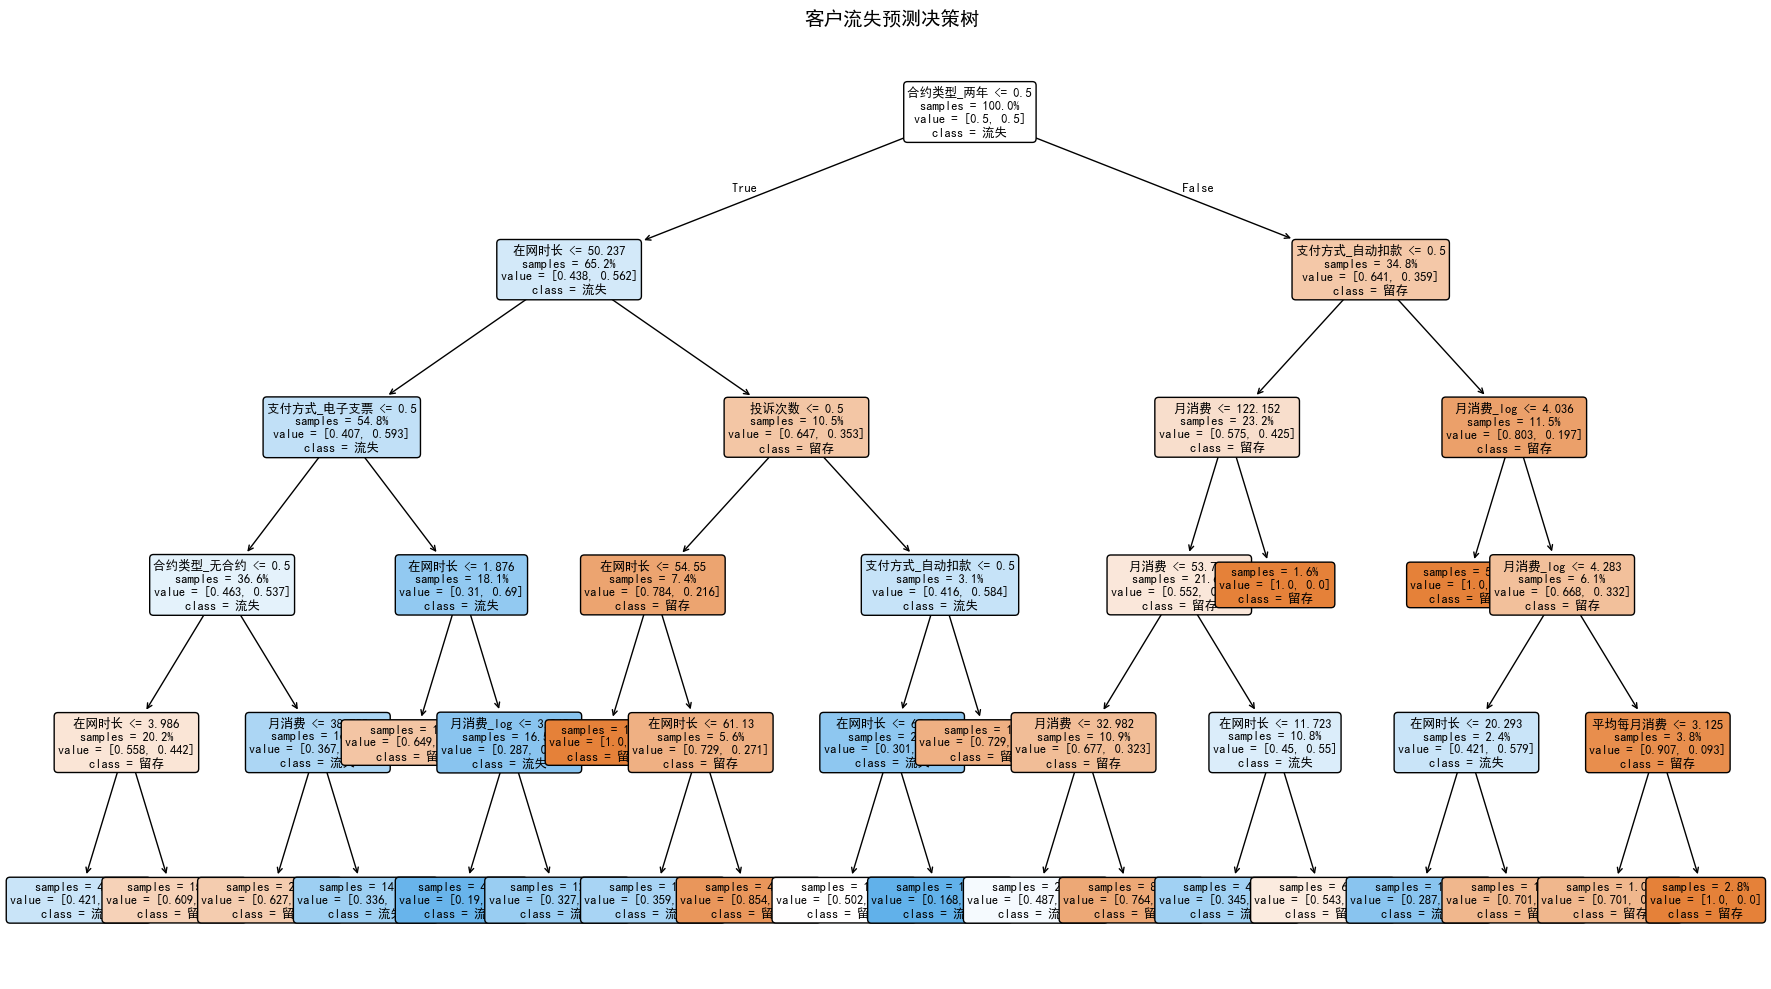

In [85]:
# 可视化决策树
fig, ax = plt.subplots(figsize=(18, 10))
plot_tree(dt_customer,
          feature_names=X_customer.columns,
          class_names=['留存', '流失'],
          filled=True,
          rounded=True,
          fontsize=9,
          ax=ax,
          impurity=False,
          proportion=True)  # 显示比例
plt.title('客户流失预测决策树', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

来，咱们用代码实现一个真正的决策树：



特征重要性:
       特征      重要性
     在网时长 0.261407
  合约类型_两年 0.172052
      月消费 0.152676
  月消费_log 0.123760
支付方式_自动扣款 0.088818
 合约类型_无合约 0.068535
支付方式_电子支票 0.065486
     投诉次数 0.057160
   平均每月消费 0.010105
   是在网老客户 0.000000


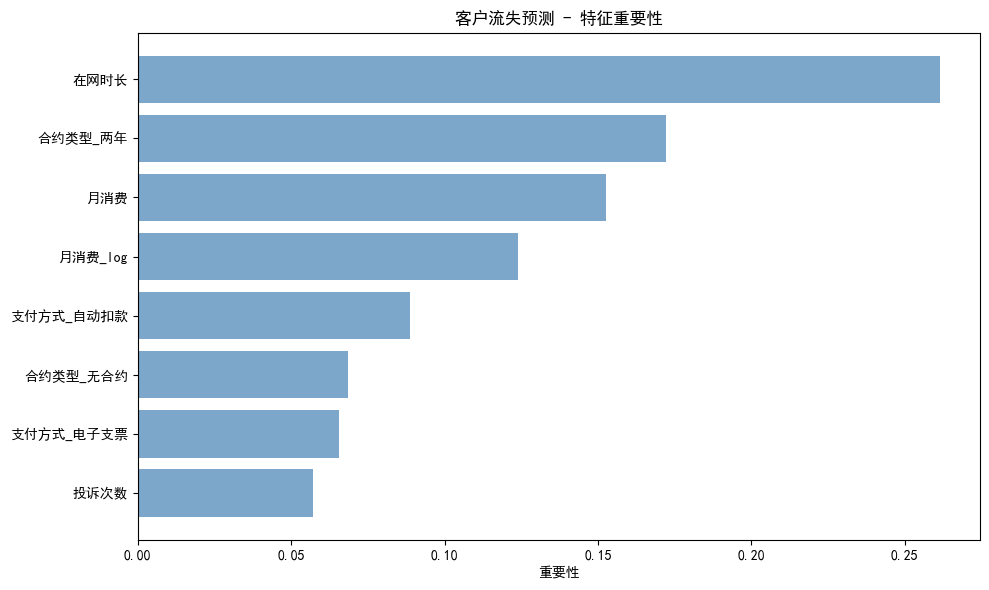

In [86]:
# 特征重要性
feature_imp = pd.DataFrame({
    '特征': X_customer.columns,
    '重要性': dt_customer.feature_importances_
}).sort_values('重要性', ascending=False)

print("\n特征重要性:")
print(feature_imp.head(10).to_string(index=False))

plt.figure(figsize=(10, 6))
plt.barh(feature_imp['特征'][:8], feature_imp['重要性'][:8], color='steelblue', alpha=0.7)
plt.xlabel('重要性')
plt.title('客户流失预测 - 特征重要性')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


---

## 九、小结

| 概念 | 说明 |
|------|------|
| **分裂准则** | 信息增益（熵）或基尼指数 |
| **过拟合** | 树太深会记住噪声而非规律 |
| **剪枝** | max_depth、min_samples_split等参数控制复杂度 |
| **特征重要性** | 基于特征带来的不纯度减少 |
| **优点** | 直观易懂、无需特征缩放、能处理非线性关系 |
| **缺点** | 容易过拟合、不稳定（数据小变化导致树大变化） |

**决策树适用场景**：
- 需要模型可解释性的业务场景
- 特征与目标有非线性关系
- 作为集成学习（随机森林、XGBoost）的基础

---

## 十、课后练习

1. 尝试不同的max_depth，观察训练/测试准确率的变化
2. 思考：为什么决策树的决策边界是轴对齐的矩形？

练习1：不同max_depth对决策树性能的影响
  max_depth=           1: 训练准确率=0.6750, 测试准确率=0.6333
  max_depth=           2: 训练准确率=0.9500, 测试准确率=0.9667
  max_depth=           3: 训练准确率=0.9500, 测试准确率=0.9667
  max_depth=           5: 训练准确率=0.9833, 测试准确率=1.0000
  max_depth=          10: 训练准确率=0.9917, 测试准确率=1.0000
  max_depth=   None(不限制): 训练准确率=0.9917, 测试准确率=1.0000


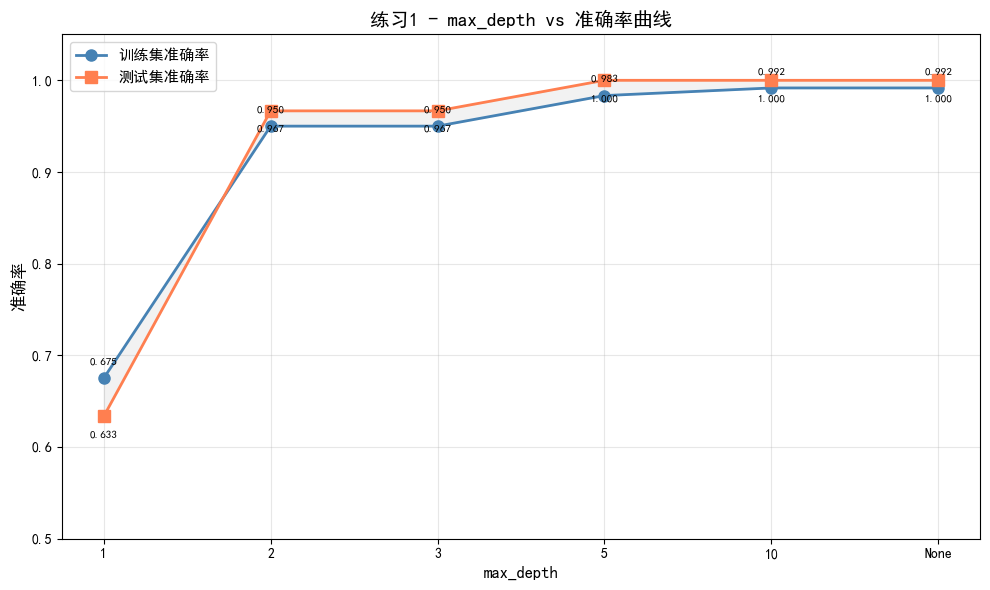

In [87]:
print("练习1：不同max_depth对决策树性能的影响")

depths = [1, 2, 3, 5, 10, None]
train_accs = []
test_accs = []

for depth in depths:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)
    train_acc = dt.score(X_train, y_train)
    test_acc = dt.score(X_test, y_test)
    train_accs.append(train_acc)
    test_accs.append(test_acc)
    depth_str = str(depth) if depth is not None else 'None(不限制)'
    print(f"  max_depth={depth_str:>12s}: 训练准确率={train_acc:.4f}, 测试准确率={test_acc:.4f}")

# 可视化
fig, ax = plt.subplots(figsize=(10, 6))
depth_labels = ['1', '2', '3', '5', '10', 'None']
ax.plot(depth_labels, train_accs, 'o-', label='训练集准确率', color='steelblue', linewidth=2, markersize=8)
ax.plot(depth_labels, test_accs, 's-', label='测试集准确率', color='coral', linewidth=2, markersize=8)
ax.fill_between(range(len(depth_labels)), train_accs, test_accs, alpha=0.1, color='gray')
ax.set_title('练习1 - max_depth vs 准确率曲线', fontsize=14)
ax.set_xlabel('max_depth', fontsize=12)
ax.set_ylabel('准确率', fontsize=12)
ax.legend(fontsize=11)
ax.set_ylim(0.5, 1.05)
ax.grid(True, alpha=0.3)

# 标注数值
for i, (tr, te) in enumerate(zip(train_accs, test_accs)):
    ax.annotate(f'{tr:.3f}', (i, tr), textcoords="offset points", xytext=(0, 10), ha='center', fontsize=8)
    ax.annotate(f'{te:.3f}', (i, te), textcoords="offset points", xytext=(0, -15), ha='center', fontsize=8)

plt.tight_layout()
plt.show()

1. 决策树的核心机制是"阈值判断"——在每个节点，它选择一个特征和一个阈值，
      将数据空间一分为二：feature_i <= threshold 和 feature_i > threshold。

   2. 这种分裂方式产生的是垂直于某个特征轴的超平面。在二维情况下，就是平行于
      坐标轴的直线；在多维情况下，就是平行于某个坐标轴的超平面。

   3. 多层分裂后，决策边界就是由一系列轴对齐的矩形（高维中是超矩形）组成。
      例如：
      - 第一次分裂：x1 <= 5 → 左右两半
      - 第二次分裂：x2 <= 3 → 上下两半
      - 最终形成的区域就是矩形

   4. 这种特性：
      - 优点：非常直观、易于解释，每个判断条件都有明确含义
      - 缺点：对于斜向的决策边界，需要很多次分裂才能近似，导致树变深
              例如对角线分界线需要"阶梯状"的矩形来近似

   5. 对比：SVM的决策边界可以任意角度，神经网络可以拟合任意形状的边界。
      决策树的轴对齐特性是它的结构决定的，也是它"简单直观"的代价。

本篇完整代码包括练习题解答都已经上传至 GitHub 仓库，欢迎 Clone。

---

## 下期预告

> **第 50 篇：随机森林 — 集成学习的威力**
>
> 下篇学随机森林——把多棵决策树「投票」组合起来，既保留了可解释性，又大大提升了准确率和稳定性。

---

*有任何问题，欢迎在评论区留言，小荷会一一回复的！*